Descriptive Statistics - Measures of Central Tendency and variability perform the following operations on any
open source dataset (e.g., data.csv)  
1. Provide summary statistics (mean, median, minimum, maximum, standard deviation) for a dataset (age,
income etc.) with numeric variables grouped by one of the qualitative (categorical) variables. For example,
if your categorical variable is age groups and quantitative variable is income, then provide summary
statistics of income grouped by the age groups. Create a list that contains a numeric value for each response
to the categorical variable.  
2. Write a Python program to display some basic statistical details like percentile, mean, standard deviation
etc. of the species of ‘Iris-setosa’, ‘Iris-versicolor’ and ‘Iris-versicolor’ of iris.csv dataset.

In [28]:
#importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Reading the dataset
df = pd.read_csv("adult.csv", skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Describing the dataset
print("\nOverall Statistics:\n")
df.describe()



Overall Statistics:



,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
print("shape and size of the data: ", df.shape, df.size)

shape and size of the data:  (32561, 15) 488415


In [8]:
#Checking for missing values
df.replace('?', pd.NA, inplace=True)
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [15]:
adult_df = df.copy()


In [16]:
adult_df.replace('?', pd.NA, inplace=True)
adult_df['age'] = pd.to_numeric(adult_df['age'], errors='coerce')
adult_df.dropna(inplace=True)

In [17]:
adult_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [19]:
adult_df.reset_index(drop=True)
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [20]:
print("\n=== Adult Dataset Summary ===\n")
adult_df.describe()


=== Adult Dataset Summary ===



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


<Axes: >

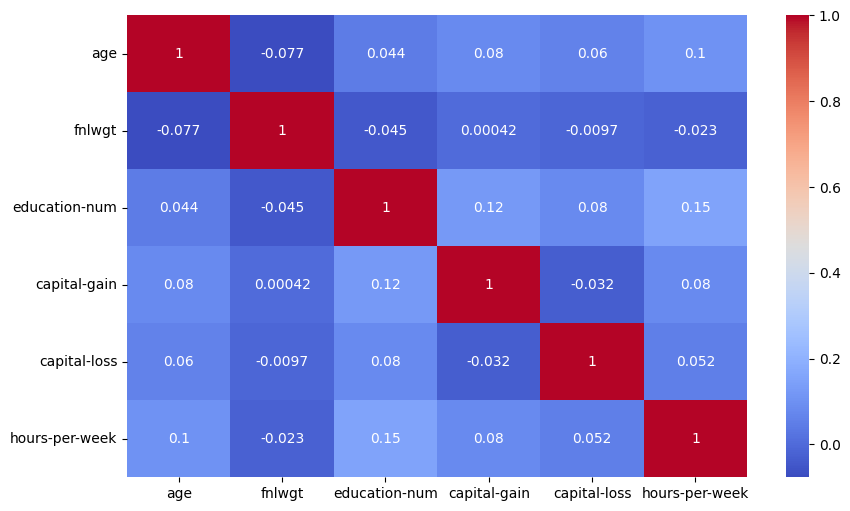

In [29]:
newdf = adult_df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 6))
sns.heatmap(newdf.corr(), annot=True, cmap='coolwarm')

In [21]:
print("\nMean age grouped by gender:\n")
print(adult_df.groupby("gender")["age"].mean())


Mean age grouped by gender:

gender
Female    36.883459
Male      39.184004
Name: age, dtype: float64


In [22]:
print("\nMedian age grouped by marital-status:\n")
print(adult_df.groupby("marital-status")["age"].median())


Median age grouped by marital-status:

marital-status
Divorced                 42.0
Married-AF-spouse        30.0
Married-civ-spouse       42.0
Married-spouse-absent    40.0
Never-married            26.0
Separated                39.0
Widowed                  58.0
Name: age, dtype: float64


In [23]:
print("\nStd deviation grouped by gender & marital-status:\n")
print(adult_df.groupby(["gender","marital-status"])["age"].std())


Std deviation grouped by gender & marital-status:

gender  marital-status       
Female  Divorced                 10.353916
        Married-AF-spouse         7.656944
        Married-civ-spouse       11.037225
        Married-spouse-absent    11.915598
        Never-married            10.241481
        Separated                10.660528
        Widowed                  11.535592
Male    Divorced                  9.837416
        Married-AF-spouse         7.195678
        Married-civ-spouse       11.647449
        Married-spouse-absent    12.199063
        Never-married             9.718488
        Separated                10.314286
        Widowed                  13.149472
Name: age, dtype: float64


In [24]:
print("\nMean age grouped by income:\n")
print(adult_df.groupby("income")["age"].mean())


Mean age grouped by income:

income
<=50K    36.60806
>50K     43.95911
Name: age, dtype: float64


In [25]:

print("\nMean age grouped by income & gender:\n")
print(adult_df.groupby(["income","gender"])["age"].mean())


Mean age grouped by income & gender:

income  gender
<=50K   Female    36.231719
        Male      36.841390
>50K    Female    41.964928
        Male      44.305816
Name: age, dtype: float64


In [26]:
# Count categories
print("\nCount of marital-status:\n")
print(adult_df["marital-status"].value_counts())


Count of marital-status:

marital-status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64


In [33]:
# ======= Iris Dataset Descriptive Statistics =======
import pandas as pd

iris_df = pd.read_csv("iris.csv")
print("\nIris dataset preview:\n", iris_df.head(), "\n", sep="")

# Confirm species list
print("Unique species:", iris_df['Species'].unique())



Iris dataset preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Unique species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [36]:
# Normalize species names and check for typos
iris_df['Species'] = iris_df['Species'].str.strip()

# Use only numeric features for statistics
numeric_cols = iris_df.select_dtypes(include=['number']).columns.tolist()

# Grouped summary statistics by Species
grouped = iris_df.groupby('Species')

print("\nSummary statistics for Iris Species (numeric columns):")
print(grouped[numeric_cols].agg(['mean', 'median', 'min', 'max', 'std']))


Summary statistics for Iris Species (numeric columns):
                    Id                            SepalLengthCm              \
                  mean median  min  max       std          mean median  min   
Species                                                                       
Iris-setosa       25.5   25.5    1   50  14.57738         5.006    5.0  4.3   
Iris-versicolor   75.5   75.5   51  100  14.57738         5.936    5.9  4.9   
Iris-virginica   125.5  125.5  101  150  14.57738         6.588    6.5  4.9   

                                ... PetalLengthCm                             \
                 max       std  ...          mean median  min  max       std   
Species                         ...                                            
Iris-setosa      5.8  0.352490  ...         1.464   1.50  1.0  1.9  0.173511   
Iris-versicolor  7.0  0.516171  ...         4.260   4.35  3.0  5.1  0.469911   
Iris-virginica   7.9  0.635880  ...         5.552   5.55  4.5  6.9  0

In [38]:

# Specific statistics required
for species in ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']:
    if species not in grouped.groups:
        print(f"\nSpecies {species} not found in dataset")
        continue
    sp = grouped.get_group(species)[numeric_cols]
    print(f"\n=== {species} ===")
    print("Mean:\n", sp.mean())
    print("Standard deviation:\n", sp.std())
    print("25th percentile:\n", sp.quantile(0.25))
    print("50th percentile (median):\n", sp.quantile(0.5))
    print("75th percentile:\n", sp.quantile(0.75))


=== Iris-setosa ===
Mean:
 Id               25.500
SepalLengthCm     5.006
SepalWidthCm      3.418
PetalLengthCm     1.464
PetalWidthCm      0.244
dtype: float64
Standard deviation:
 Id               14.577380
SepalLengthCm     0.352490
SepalWidthCm      0.381024
PetalLengthCm     0.173511
PetalWidthCm      0.107210
dtype: float64
25th percentile:
 Id               13.250
SepalLengthCm     4.800
SepalWidthCm      3.125
PetalLengthCm     1.400
PetalWidthCm      0.200
Name: 0.25, dtype: float64
50th percentile (median):
 Id               25.5
SepalLengthCm     5.0
SepalWidthCm      3.4
PetalLengthCm     1.5
PetalWidthCm      0.2
Name: 0.5, dtype: float64
75th percentile:
 Id               37.750
SepalLengthCm     5.200
SepalWidthCm      3.675
PetalLengthCm     1.575
PetalWidthCm      0.300
Name: 0.75, dtype: float64

=== Iris-versicolor ===
Mean:
 Id               75.500
SepalLengthCm     5.936
SepalWidthCm      2.770
PetalLengthCm     4.260
PetalWidthCm      1.326
dtype: float64
Standa

In [39]:

# Quantile for whole dataset by feature
overall_quantiles = iris_df[numeric_cols].quantile([0.25, 0.5, 0.75])
print("\nOverall percentiles for numeric features:\n", overall_quantiles)


Overall percentiles for numeric features:
           Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0.25   38.25            5.1           2.8           1.60           0.3
0.50   75.50            5.8           3.0           4.35           1.3
0.75  112.75            6.4           3.3           5.10           1.8
